In [1]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# IMPORTANDO DADOS

In [2]:
df = pd.read_csv('Target/output/data.csv')
df

,time,target_wz,target_tmp,target_pitch,target_e,target_ay,target_ax,target_wx,target_wy,target_az,target_roll,target_yaw,static
0,0.0,-6.92455,53.0,-1.525,-22.176,10.733555,0.194623,-47.92960,-1.16726,-0.614769,18.043,2.936,False
1,0.1,-8.13221,52.9,-0.742,-16.704,11.618576,0.294719,-58.13591,-1.05996,-0.532550,12.732,2.725,False
2,0.2,-8.42212,53.1,0.119,-10.440,12.899422,0.256924,-67.53252,-1.95110,-2.312996,6.586,2.578,False
3,0.3,-9.92099,53.3,1.010,-3.240,12.406766,0.425020,-67.39252,-1.05936,-0.455019,-0.016,2.655,False
4,0.4,-9.44709,52.9,1.984,3.744,12.362390,0.271203,-66.62502,-1.97845,-0.208931,-6.779,2.656,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2796,279.5,-0.00493,55.6,1.368,-1.692,9.717615,0.235938,-0.09929,-0.03678,-0.402014,-2.509,5.289,True
2797,279.6,0.50338,55.4,1.367,-1.692,9.768983,0.257170,-0.18597,0.40111,-0.404622,-2.506,5.291,True
2798,279.7,0.14588,55.6,1.367,-1.692,9.796167,0.266545,0.06592,-0.14609,-0.485586,-2.506,5.289,True
2799,279.8,0.04660,55.5,1.367,-1.692,9.755871,0.222170,-0.01801,-0.00522,-0.409330,-2.504,5.290,True


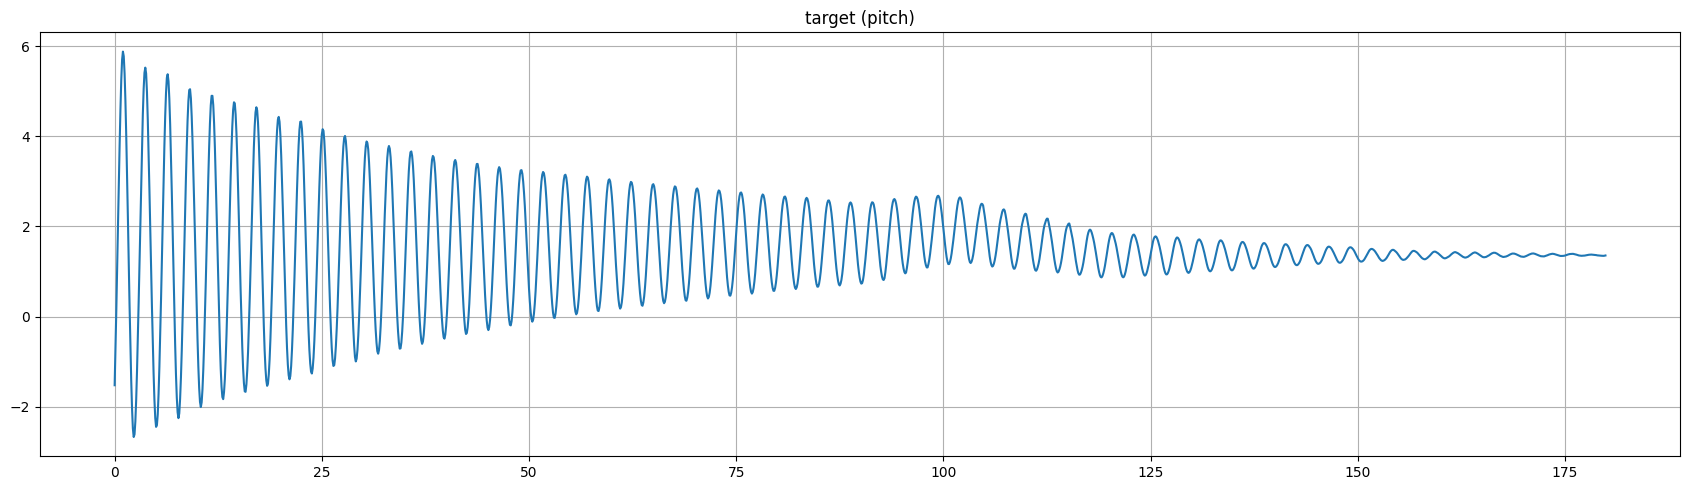

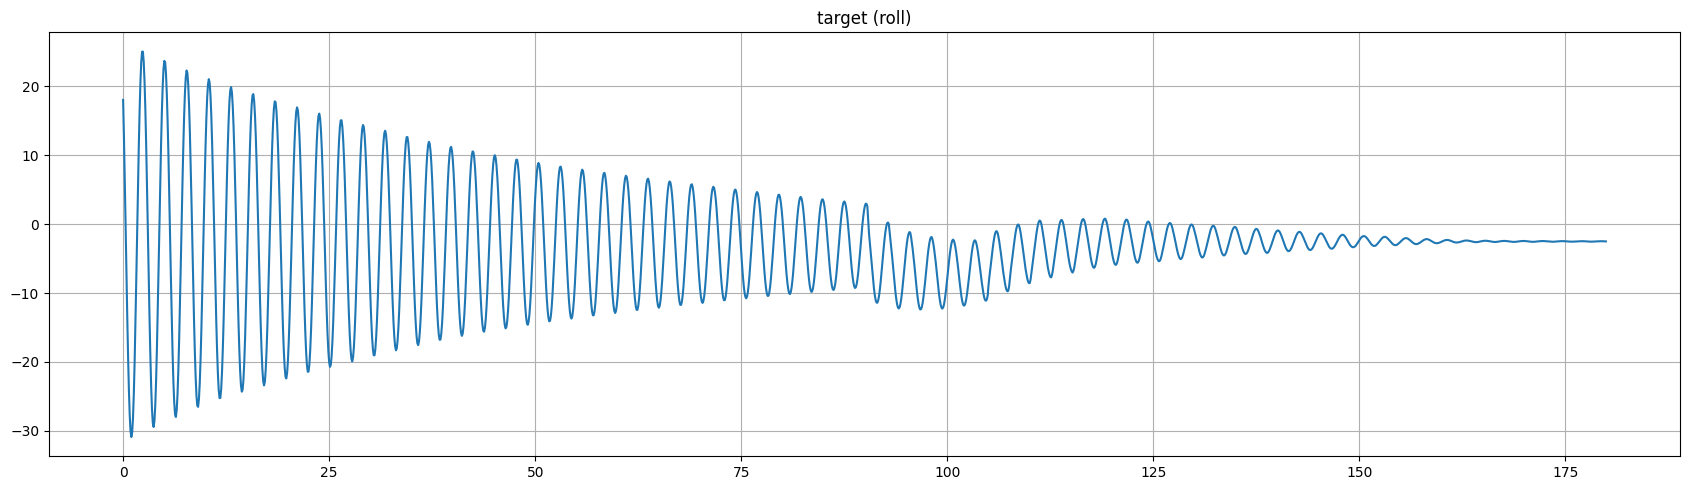

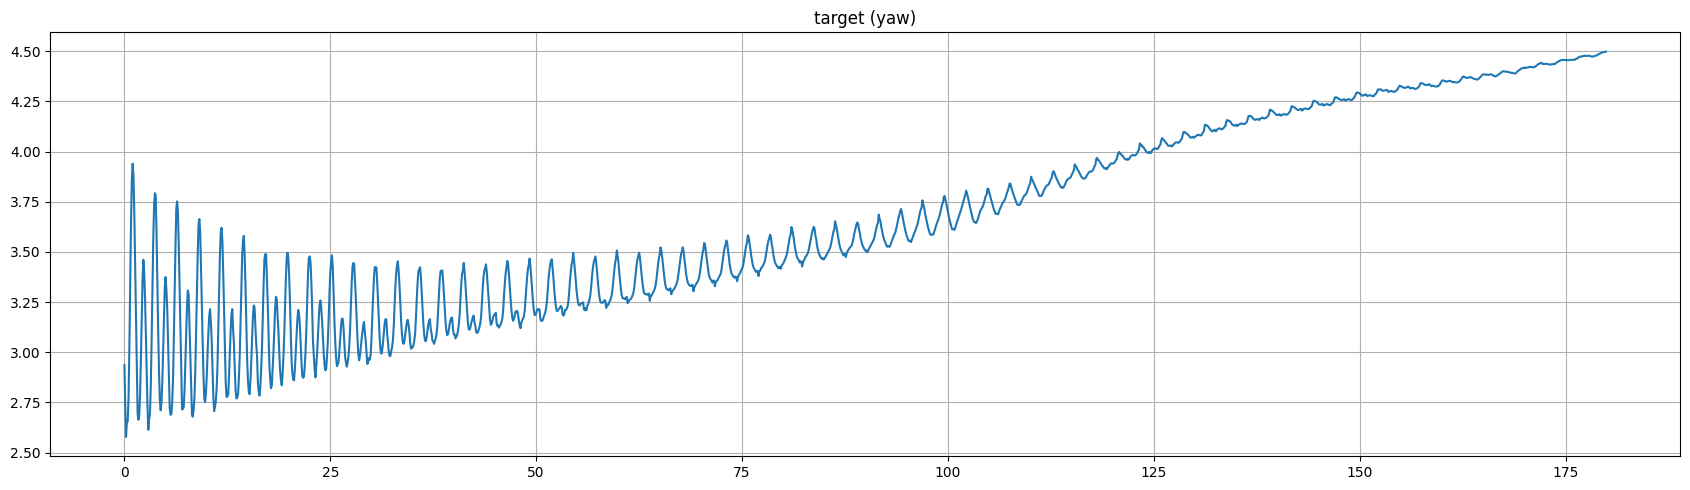

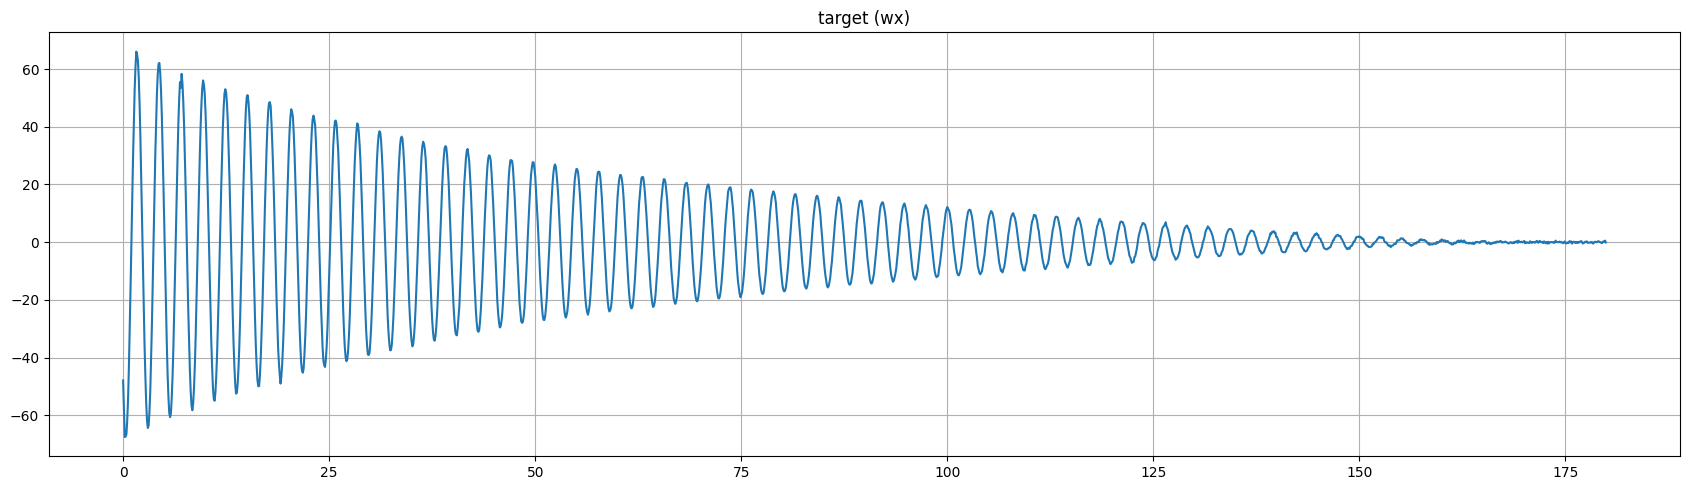

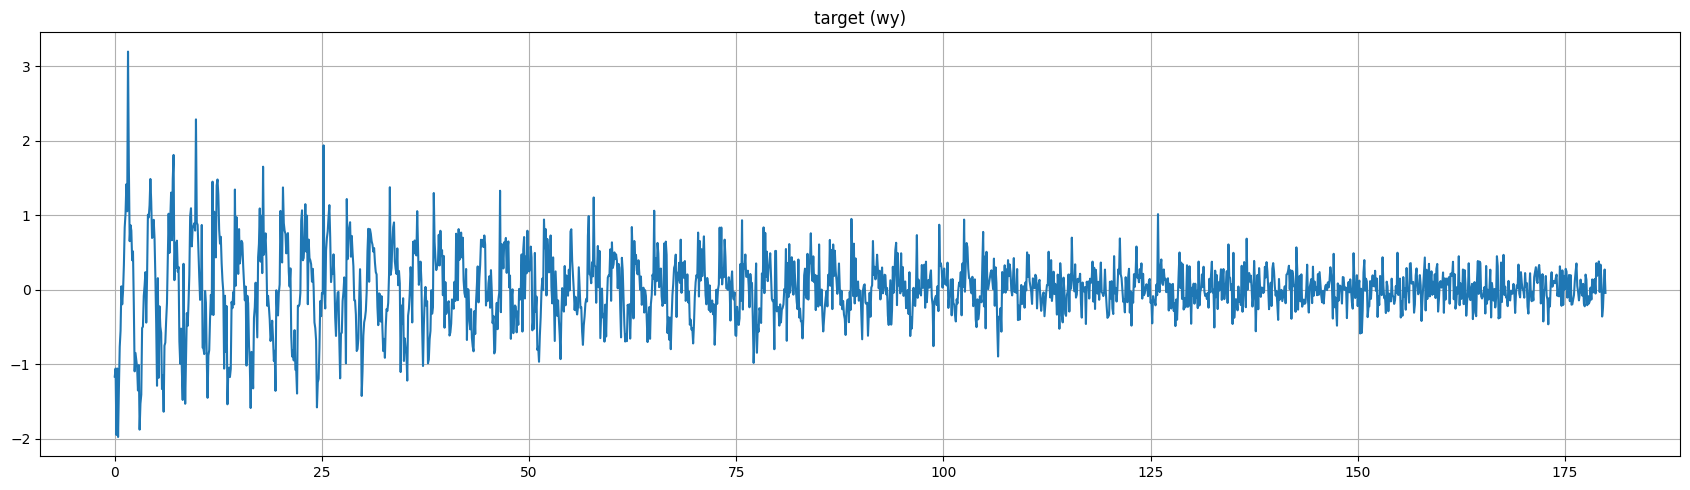

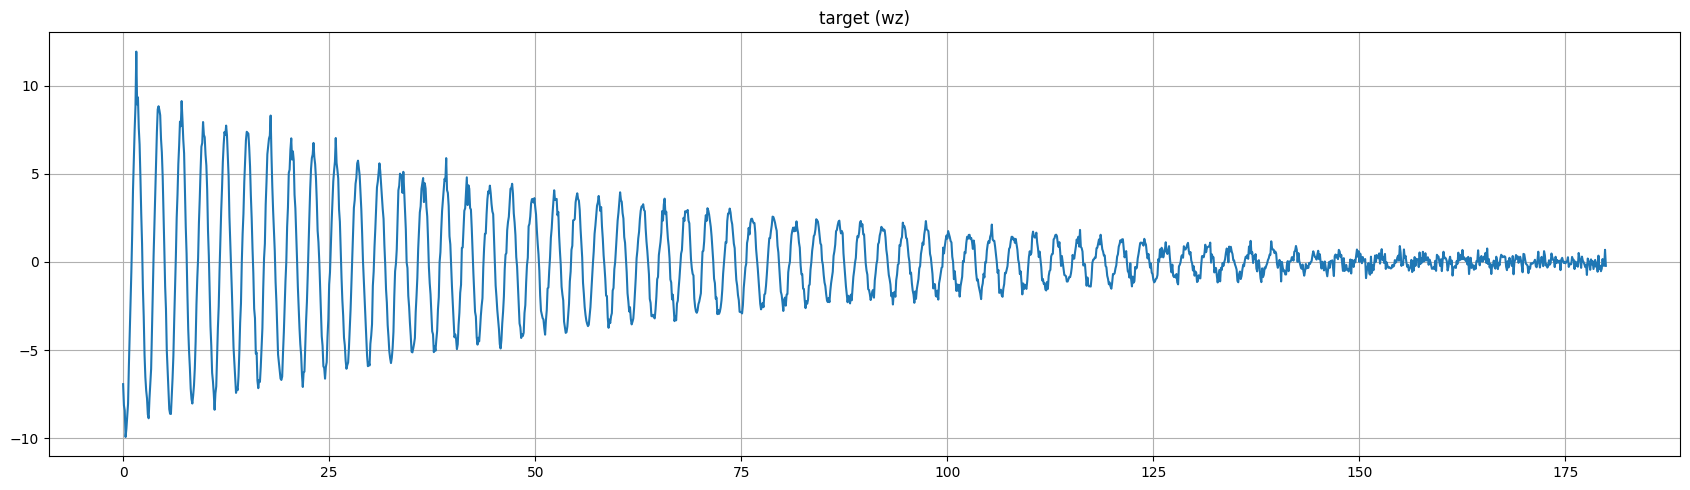

In [3]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})': df.loc[~df.static][f'target_{var}']
    }, time=df.loc[~df.static].time, figsize=(17, 5))

# REMOVENDO A BARRIGUINHA

In [4]:
def clearBarriguinha(df, undesired=(45, 80)):
    # Desempacota os limites do intervalo
    start_time, _ = undesired

    # 1. Pega os dados dinâmicos apenas ANTES da barriguinha
    df_dynamic_before = df[(~df['static']) & (df['time'] < start_time)].copy()

    # 2. Pega todos os dados estáticos intactos
    df_static = df[df['static']].copy()

    # 3. Junta os dois e reseta o índice, sem alterar o tempo original
    df_cleaned = pd.concat([df_dynamic_before, df_static]).sort_values(by='time').reset_index(drop=True)

    return df_cleaned



test = json.loads(open('../info.json', 'r', encoding='utf-8').read())['target']['test']
axis = json.loads(open('../info.json', 'r', encoding='utf-8').read())['target']['axis']
interval = json.loads(open(f'files/test{test}/rolling_{axis}/info.json', 'r', encoding='utf-8').read()).get('belly')
print(interval)

df = clearBarriguinha(df, interval)
df.head()

[80, 125]


,time,target_wz,target_tmp,target_pitch,target_e,target_ay,target_ax,target_wx,target_wy,target_az,target_roll,target_yaw,static
0,0.0,-6.92455,53.0,-1.525,-22.176,10.733555,0.194623,-47.92960,-1.16726,-0.614769,18.043,2.936,False
1,0.1,-8.13221,52.9,-0.742,-16.704,11.618576,0.294719,-58.13591,-1.05996,-0.532550,12.732,2.725,False
2,0.2,-8.42212,53.1,0.119,-10.440,12.899422,0.256924,-67.53252,-1.95110,-2.312996,6.586,2.578,False
3,0.3,-9.92099,53.3,1.010,-3.240,12.406766,0.425020,-67.39252,-1.05936,-0.455019,-0.016,2.655,False
4,0.4,-9.44709,52.9,1.984,3.744,12.362390,0.271203,-66.62502,-1.97845,-0.208931,-6.779,2.656,False


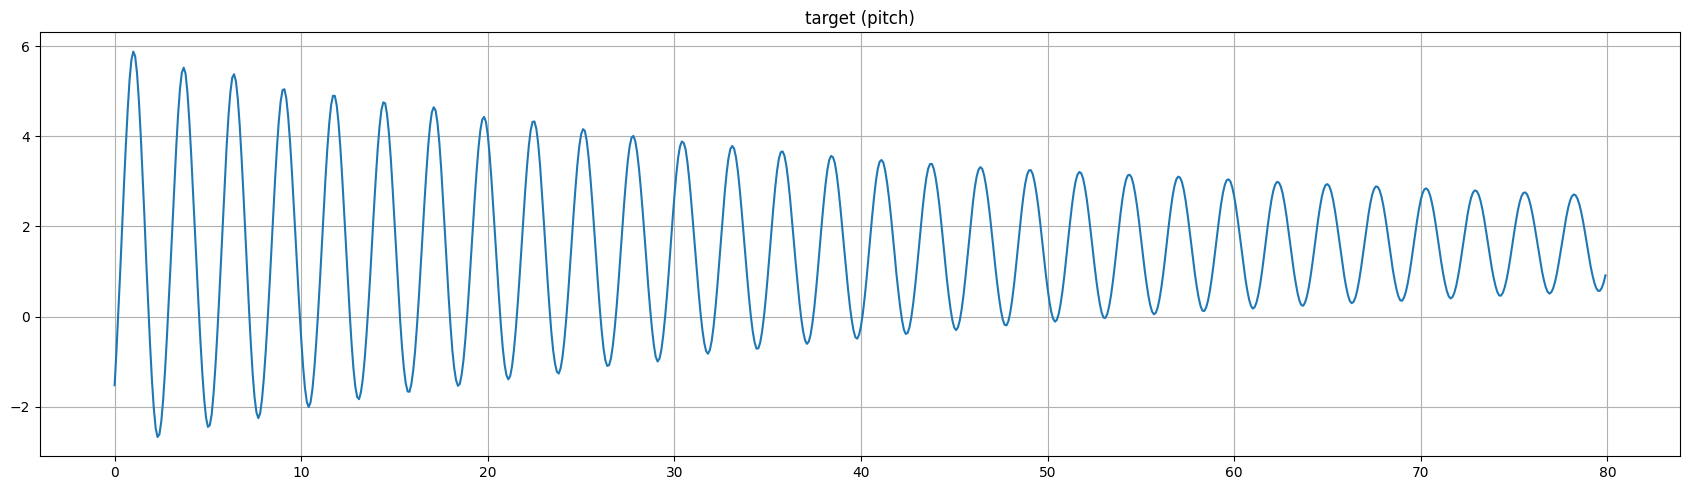

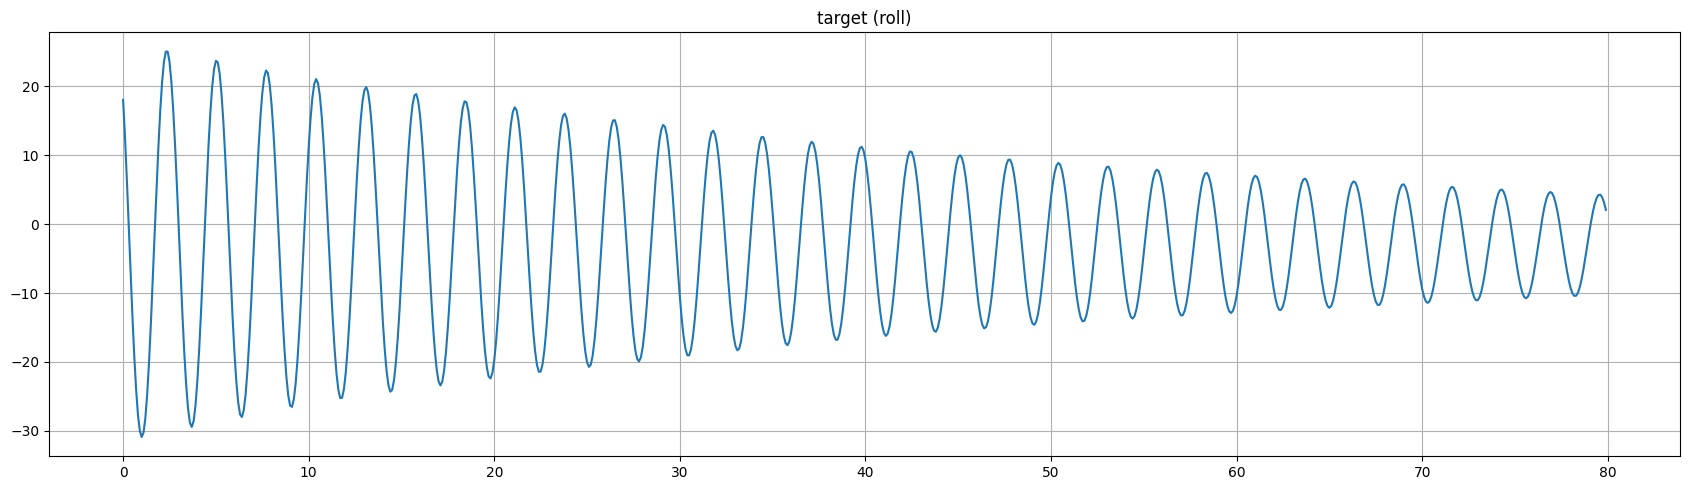

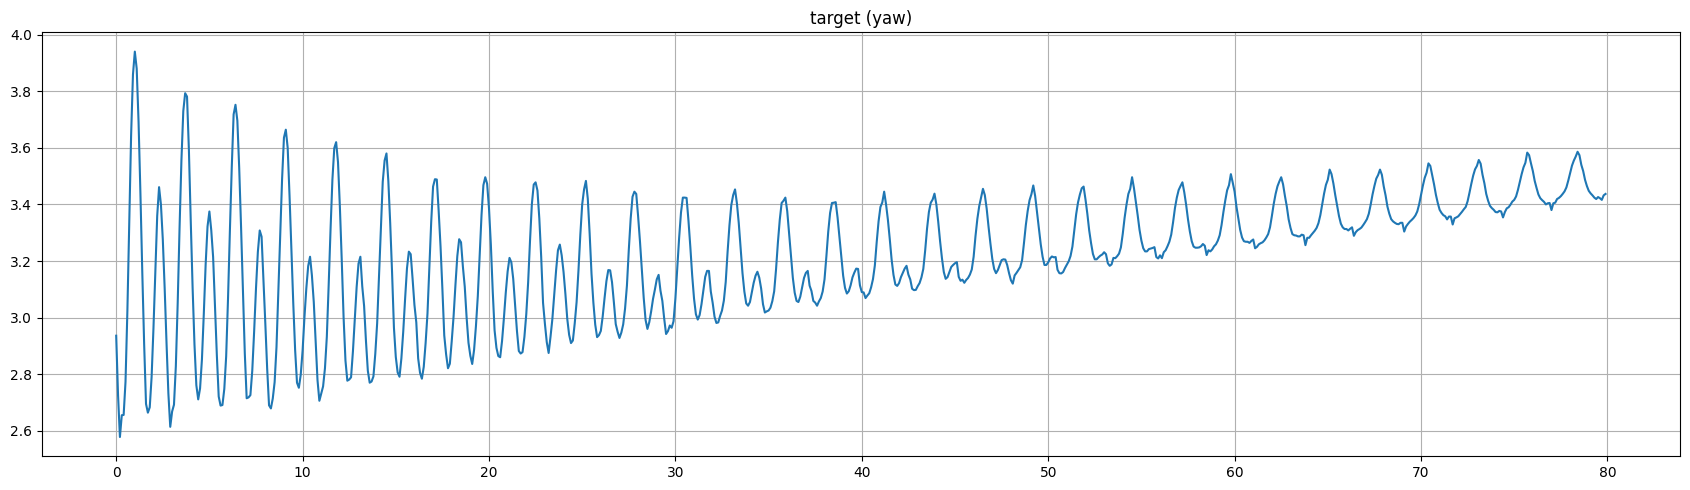

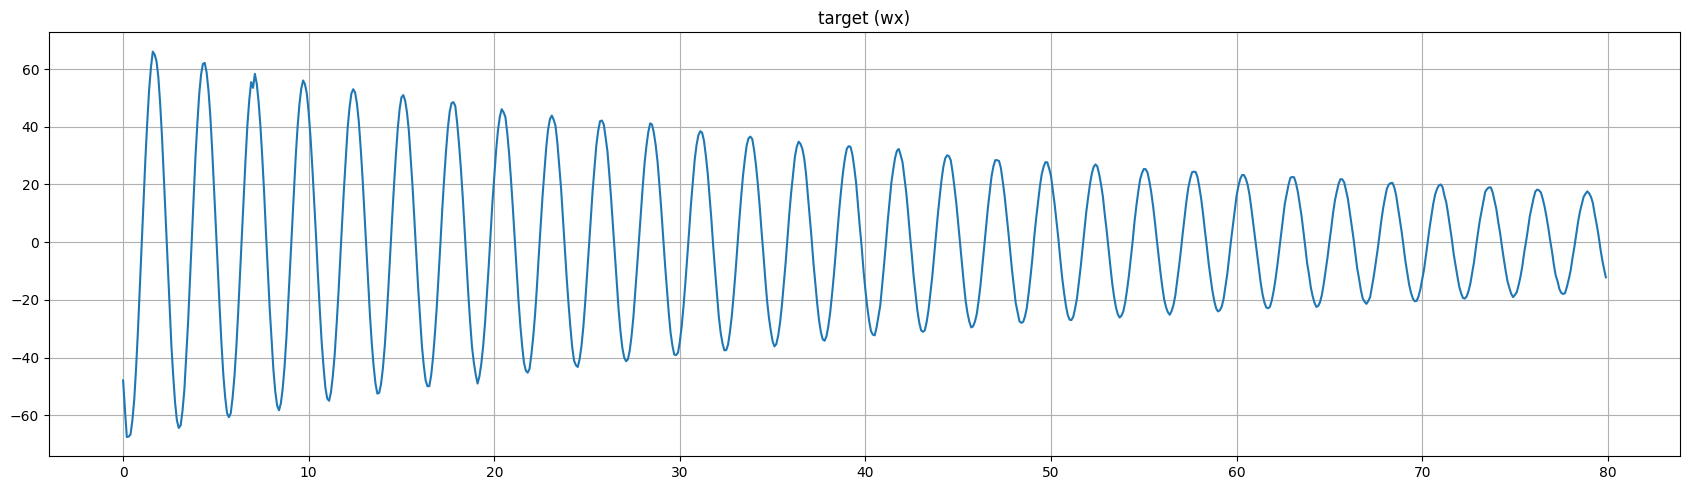

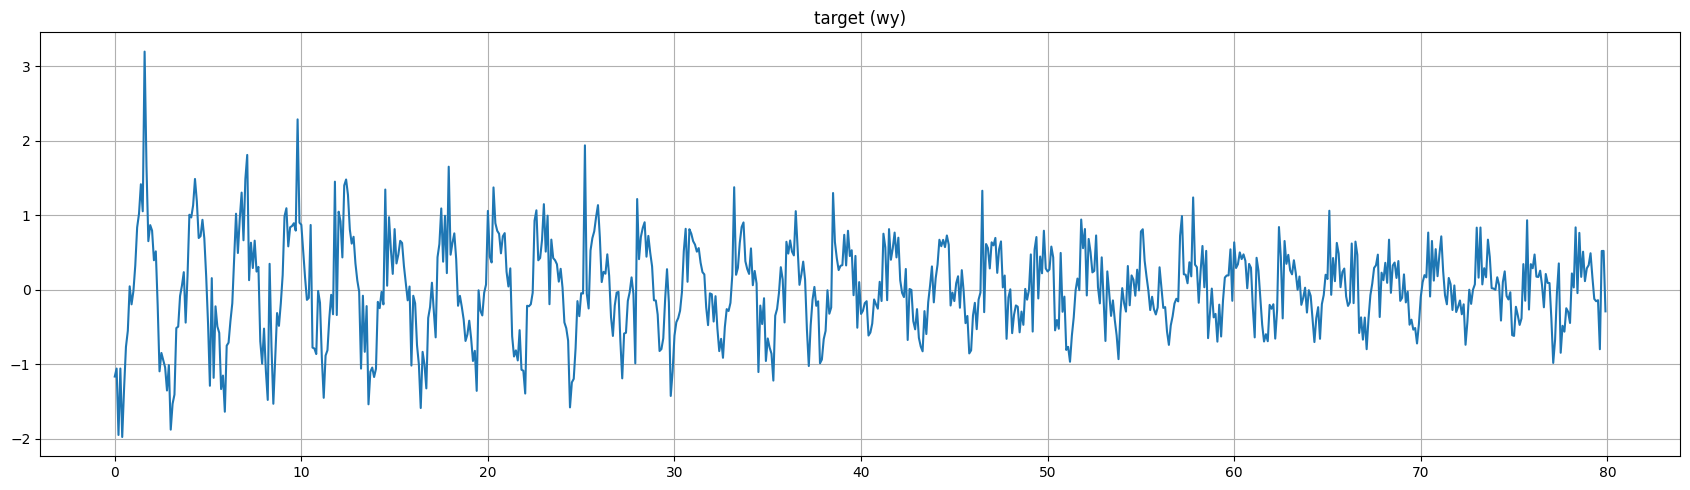

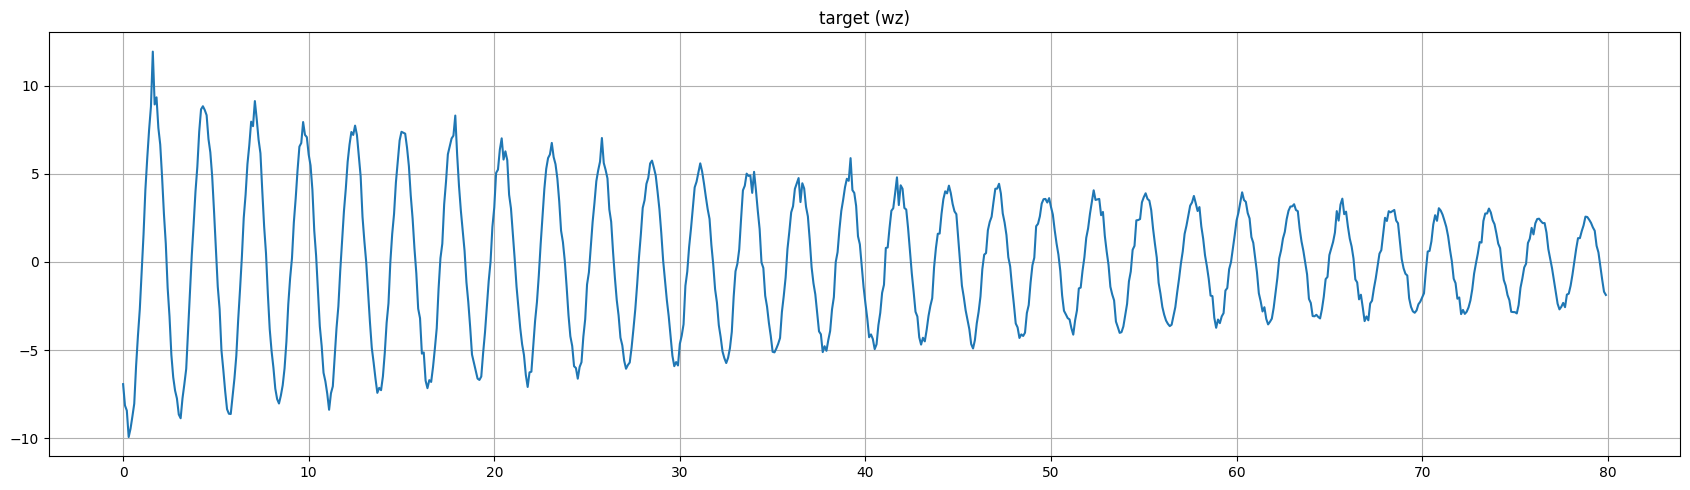

In [5]:
for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df.loc[~df.static][f'target_{var}']
    }, time=df.loc[~df.static].time, figsize=(17, 5))

# SALVANDO DADOS

In [6]:
os.makedirs('files', exist_ok=True)
df.to_csv('files/output.csv', index=None)